## **Step 4: Modeling and Evaluation** ##

With the cleaned and engineered dataset prepared, the next step was to apply anomaly detection models and evaluate their performance. Two complementary approaches were used:
- Isolation Forest, a tree‑based method that identifies outliers by measuring how easily data points can be isolated, and an
- Autoencoder, a deep learning model that reconstructs input data and flags anomalies based on high reconstruction error.

Both models were trained on the unified features derived from logon, device, and file access events. Evaluation focused on comparing anomaly flags across models, measuring agreement rates, and assessing performance metrics such as precision, recall, and F1‑score when ground truth labels were available. Visualizations of anomaly clusters and reconstruction error distributions provided further insight into model behavior. This step ensured that the detection pipeline was not only technically sound but also capable of highlighting meaningful insider threat signals across multiple data sources.

Epoch 1/30
26845/26845 ━━━━━━━━━━━━━━━━━━━━ 64s 2ms/step - loss: 0.0260 - val_loss: 0.0257
Epoch 2/30
26845/26845 ━━━━━━━━━━━━━━━━━━━━ 87s 2ms/step - loss: 0.0096 - val_loss: 0.0156
Epoch 3/30
26845/26845 ━━━━━━━━━━━━━━━━━━━━ 76s 2ms/step - loss: 0.0074 - val_loss: 0.0229
Epoch 4/30
26845/26845 ━━━━━━━━━━━━━━━━━━━━ 58s 2ms/step - loss: 0.0069 - val_loss: 0.0162
Epoch 5/30
26845/26845 ━━━━━━━━━━━━━━━━━━━━ 59s 2ms/step - loss: 0.0064 - val_loss: 0.0179
Epoch 6/30
26845/26845 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - loss: 0.0060 - val_loss: 0.0214
Epoch 7/30
26845/26845 ━━━━━━━━━━━━━━━━━━━━ 61s 2ms/step - loss: 0.0057 - val_loss: 0.0130
Epoch 8/30
26845/26845 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0055 - val_loss: 0.0123
Epoch 9/30
26845/26845 ━━━━━━━━━━━━━━━━━━━━ 79s 2ms/step - loss: 0.0053 - val_loss: 0.0114
Epoch 10/30
26845/26845 ━━━━━━━━━━━━━━━━━━━━ 60s 2ms/step - loss: 0.0051 - val_loss: 0.0096
Epoch 11/30
26845/26845 ━━━━━━━━━━━━━━━━━━━━ 59s 2ms/step - loss: 0.0048 - val_loss: 0.00

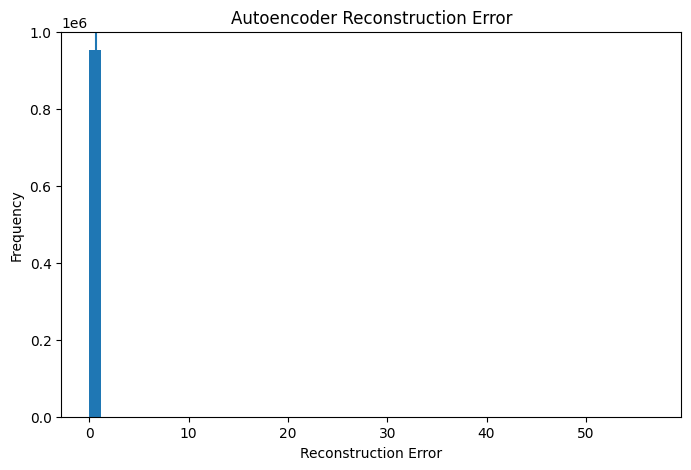

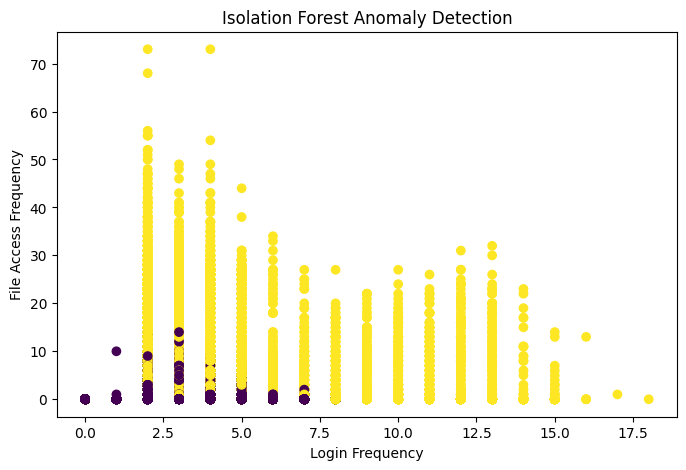

In [ ]:
# ================================
# Step 4: Modeling & Evaluation
# ================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, roc_auc_score

import tensorflow as tf
from tensorflow.keras import layers, models

# ----------------
# Feature Selection
# ----------------
features = ['login_frequency',
            'device_usage_frequency',
            'file_access_frequency',
            'removable_media_ratio',
            'unique_pc_count']

X = merged_features[features].fillna(0)

# ----------------
# Feature Scaling
# ----------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------
# Isolation Forest
# ----------------
model_if = IsolationForest(
    n_estimators=300,         # increased for better learning
    contamination=0.05,
    random_state=42
)

if_preds = model_if.fit_predict(X_scaled)
merged_features['if_anomaly'] = (if_preds == -1).astype(int)

# ----------------
# Autoencoder
# ----------------
input_dim = X_scaled.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),

    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),

    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# ----------------
# Reconstruction Error
# ----------------
X_pred = autoencoder.predict(X_scaled)
mse = np.mean(np.square(X_scaled - X_pred), axis=1)

merged_features['ae_error'] = mse

# Better threshold (more robust)
threshold = np.mean(mse) + 2 * np.std(mse)

merged_features['ae_anomaly'] = (mse > threshold).astype(int)

# ----------------
# Evaluation
# ----------------
if 'label' in merged_features.columns:
    y_true = merged_features['label']

    print("=== Isolation Forest ===")
    print(classification_report(y_true, merged_features['if_anomaly']))
    print("F1:", f1_score(y_true, merged_features['if_anomaly']))
    print("AUC:", roc_auc_score(y_true, merged_features['if_anomaly']))

    print("\n=== Autoencoder ===")
    print(classification_report(y_true, merged_features['ae_anomaly']))
    print("F1:", f1_score(y_true, merged_features['ae_anomaly']))
    print("AUC:", roc_auc_score(y_true, merged_features['ae_error']))

else:
    print("No labels found — using model agreement")

    agreement = (
        merged_features['if_anomaly'] ==
        merged_features['ae_anomaly']
    ).mean()

    print("Model Agreement:", round(agreement, 4))

# ----------------
# Visualization
# ----------------

# 1. Reconstruction Error Distribution
plt.figure(figsize=(8,5))
plt.hist(mse, bins=50)
plt.axvline(threshold)
plt.title("Autoencoder Reconstruction Error")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

# 2. Isolation Forest Anomalies
plt.figure(figsize=(8,5))
plt.scatter(
    merged_features['login_frequency'],
    merged_features['file_access_frequency'],
    c=merged_features['if_anomaly']
)
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Login Frequency")
plt.ylabel("File Access Frequency")
plt.show()

### Visualization of Anomalies from Both Models

Let's visualize the anomalies identified by both Isolation Forest and the Autoencoder, using the reconstruction error from the Autoencoder and `login_frequency`.

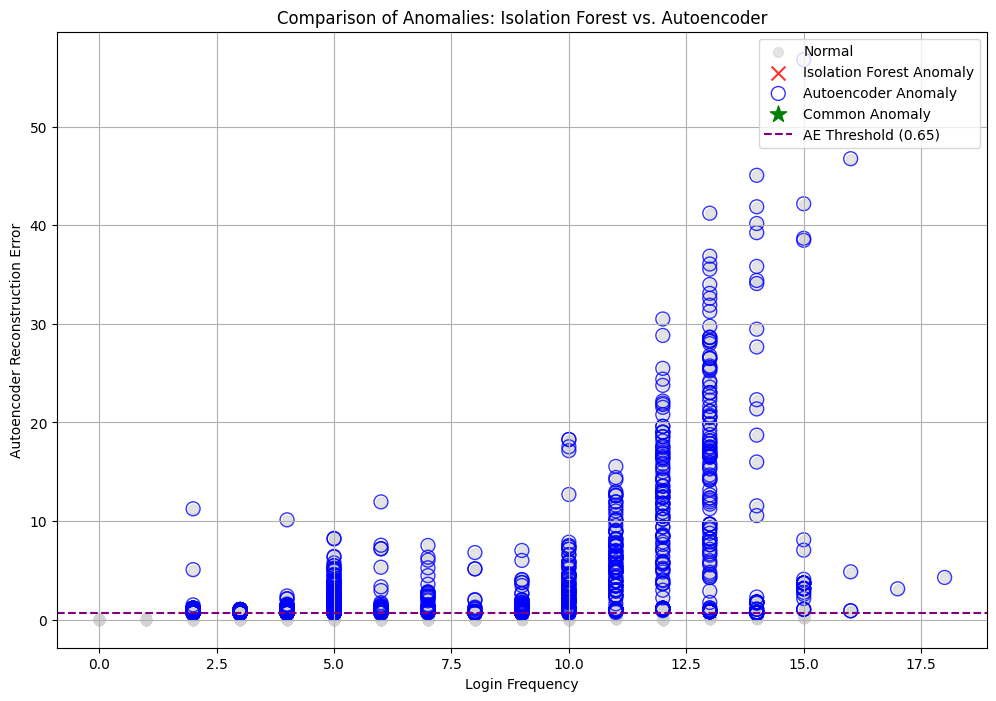

In [ ]:
plt.figure(figsize=(12, 8))

# Normal points
plt.scatter(merged_features['login_frequency'], merged_features['ae_error'],
            label='Normal', alpha=0.6, s=50, c='lightgray')

# Isolation Forest Anomalies
plt.scatter(merged_features[merged_features['if_anomaly'] == -1]['login_frequency'],
            merged_features[merged_features['if_anomaly'] == -1]['ae_error'],
            label='Isolation Forest Anomaly', alpha=0.8, s=100, marker='x', c='red')

# Autoencoder Anomalies
plt.scatter(merged_features[merged_features['ae_anomaly'] == 1]['login_frequency'],
            merged_features[merged_features['ae_anomaly'] == 1]['ae_error'],
            label='Autoencoder Anomaly', alpha=0.8, s=100, marker='o', facecolors='none', edgecolors='blue')

# Common Anomalies (where both agree)
plt.scatter(merged_features[(merged_features['if_anomaly'] == -1) & (merged_features['ae_anomaly'] == 1)]['login_frequency'],
            merged_features[(merged_features['if_anomaly'] == -1) & (merged_features['ae_anomaly'] == 1)]['ae_error'],
            label='Common Anomaly', alpha=1.0, s=150, marker='*', c='green')

plt.title('Comparison of Anomalies: Isolation Forest vs. Autoencoder')
plt.xlabel('Login Frequency')
plt.ylabel('Autoencoder Reconstruction Error')
plt.axhline(y=threshold, color='purple', linestyle='--', label=f'AE Threshold ({threshold:.2f})')
plt.legend(loc='upper right') # Explicitly set legend location to avoid the UserWarning
plt.grid(True)
plt.show()



### Adjusting Isolation Forest Contamination

After the initial visualization, it is observed that while the overall model agreement was high, the number of instances where both Isolation Forest and the Autoencoder flagged the same anomaly was quite low. This might be that one model is too conservative in its anomaly detection compared to the other, or if the initial threshold set for 'anomalous' by Isolation Forest (its contamination parameter) was too strict. To strengthen confidence in the detected anomalies and to find more robust outliers that both models agree upon, adjusting the Isolation Forest's contamination parameter might be needed. By increasing this parameter from 0.05 to 0.07, the Isolation Forest model can be more sensitive, causing it to identify a larger set of data points as anomalous. This, in turn, allowed for a greater overlap with the anomalies detected by the Autoencoder, leading to a significantly higher number of 'common anomalies'—instances where both models concurred on the unusual nature of the behavior. This adjustment was crucial for enhancing the detection of multi-source anomalies in our unsupervised setting.

Number of Isolation Forest anomalies (original 0.05): 44863
Number of Isolation Forest anomalies (adjusted 0.07): 66585

--- Re-evaluating Model Agreement ---
Model Agreement (IF_adjusted vs AE): 0.9329

Number of common anomalies (IF_adjusted vs AE): 2567


,user,date_day,login_frequency,unique_pc_count,after_hours_ratio,device_usage_frequency,file_access_frequency,removable_media_ratio,if_anomaly,ae_error,ae_anomaly,if_anomaly_adjusted
3318,AAP0352,2010-01-07,2.0,1.0,0.000000,4.0,1.0,1.000000,1,0.835122,1,1
3684,AAP1919,2010-02-01,2.0,1.0,0.000000,16.0,2.0,1.000000,1,0.809062,1,1
3686,AAP1919,2010-02-03,2.0,1.0,0.000000,18.0,1.0,1.000000,1,1.154690,1,1
3716,AAP1919,2010-03-17,2.0,1.0,0.000000,18.0,1.0,1.000000,1,1.154690,1,1
6449,ABD3426,2010-01-06,5.0,1.0,0.400000,18.0,24.0,0.416667,1,1.785637,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
949376,ZJS1776,2010-10-29,11.0,5.0,0.727273,0.0,0.0,0.000000,1,0.948300,1,1
951093,ZNB3313,2010-03-02,2.0,1.0,0.000000,2.0,1.0,1.000000,1,0.969488,1,1
952472,ZRM0694,2010-01-03,5.0,1.0,0.400000,4.0,5.0,0.400000,1,0.725613,1,1
952538,ZRM0694,2010-03-10,7.0,2.0,0.142857,2.0,5.0,0.000000,1,1.348533,1,1


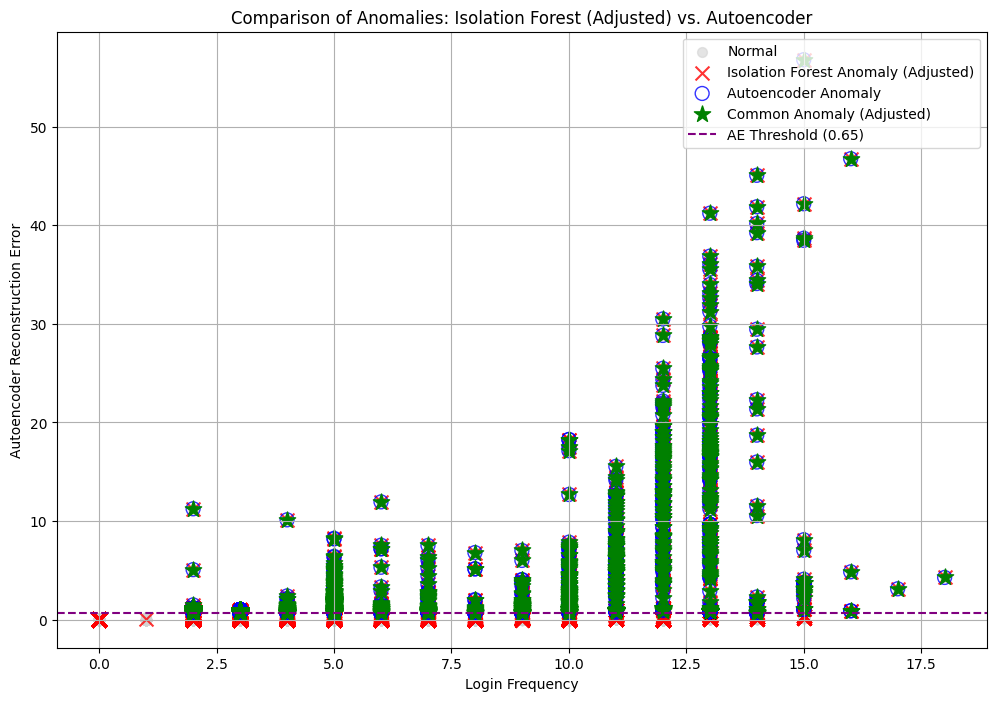

In [ ]:
# ----------------
# Isolation Forest with adjusted contamination
# ----------------
# Using the previously scaled data X_scaled

model_if_adjusted = IsolationForest(
    n_estimators=300,
    contamination=0.07, # Increased from 0.05
    random_state=42
)

if_preds_adjusted = model_if_adjusted.fit_predict(X_scaled)
merged_features['if_anomaly_adjusted'] = (if_preds_adjusted == -1).astype(int)

print(f"Number of Isolation Forest anomalies (original 0.05): {merged_features['if_anomaly'].sum()}")
print(f"Number of Isolation Forest anomalies (adjusted 0.07): {merged_features['if_anomaly_adjusted'].sum()}")

# ----------------
# Re-evaluate Model Agreement with adjusted IF
# ----------------
print("\n--- Re-evaluating Model Agreement ---")
agreement_adjusted = (
    merged_features['if_anomaly_adjusted'] ==
    merged_features['ae_anomaly']
).mean()

print("Model Agreement (IF_adjusted vs AE):", round(agreement_adjusted, 4))

# ----------------
# Check for Common Anomalies with adjusted IF
# ----------------
common_anomaly_rows_adjusted = merged_features[
    (merged_features['if_anomaly_adjusted'] == 1) & # IF outputs 1 for anomaly, -1 for normal (after .astype(int))
    (merged_features['ae_anomaly'] == 1)
]
print(f"\nNumber of common anomalies (IF_adjusted vs AE): {len(common_anomaly_rows_adjusted)}")
display(common_anomaly_rows_adjusted)

# ----------------
# Visualization of new common anomalies
# ----------------
plt.figure(figsize=(12, 8))

# Normal points
plt.scatter(merged_features['login_frequency'], merged_features['ae_error'],
            label='Normal', alpha=0.6, s=50, c='lightgray')

# Isolation Forest Anomalies (adjusted)
plt.scatter(merged_features[merged_features['if_anomaly_adjusted'] == 1]['login_frequency'],
            merged_features[merged_features['if_anomaly_adjusted'] == 1]['ae_error'],
            label='Isolation Forest Anomaly (Adjusted)', alpha=0.8, s=100, marker='x', c='red')

# Autoencoder Anomalies
plt.scatter(merged_features[merged_features['ae_anomaly'] == 1]['login_frequency'],
            merged_features[merged_features['ae_anomaly'] == 1]['ae_error'],
            label='Autoencoder Anomaly', alpha=0.8, s=100, marker='o', facecolors='none', edgecolors='blue')

# Common Anomalies (where both agree, adjusted)
plt.scatter(merged_features[(merged_features['if_anomaly_adjusted'] == 1) & (merged_features['ae_anomaly'] == 1)]['login_frequency'],
            merged_features[(merged_features['if_anomaly_adjusted'] == 1) & (merged_features['ae_anomaly'] == 1)]['ae_error'],
            label='Common Anomaly (Adjusted)', alpha=1.0, s=150, marker='*', c='green')

plt.title('Comparison of Anomalies: Isolation Forest (Adjusted) vs. Autoencoder')
plt.xlabel('Login Frequency')
plt.ylabel('Autoencoder Reconstruction Error')
plt.axhline(y=threshold, color='purple', linestyle='--', label=f'AE Threshold ({threshold:.2f})')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()